# Importing

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import re

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('HBS03.csv')

In [ ]:
df

,Statistic Label,Year,Household Disposable Income Quintiles,Expenditure,UNIT,VALUE
0,Average weekly household expenditure,2023,1st quintile,Total average weekly household expenditure (00...,Euro,444.00
1,Average weekly household expenditure,2023,1st quintile,Total food (01),Euro,78.91
2,Average weekly household expenditure,2023,1st quintile,Total food consumed at home (01.01),Euro,67.71
3,Average weekly household expenditure,2023,1st quintile,Bread (including retail sandwiches) (01.01.01),Euro,4.21
4,Average weekly household expenditure,2023,1st quintile,Flour (01.01.02),Euro,0.11
...,...,...,...,...,...,...
589,Average weekly household expenditure,2023,All quintiles,Childcare (09.17),Euro,6.38
590,Average weekly household expenditure,2023,All quintiles,"Other care, domestic and household services (0...",Euro,5.69
591,Average weekly household expenditure,2023,All quintiles,Charitable donations and subscriptions (09.19),Euro,2.50
592,Average weekly household expenditure,2023,All quintiles,Other money given to other persons (09.20),Euro,16.15


In [ ]:
df['Household Disposable Income Quintiles'].unique()

array(['1st quintile', '2nd quintile', '3rd quintile', '4th quintile',
       '5th quintile', 'All quintiles'], dtype=object)

In [ ]:
df['Statistic Label'].unique()

array(['Average weekly household expenditure'], dtype=object)

# Data Shaping

## Renaming

In [ ]:
df['Expenditure'] = df['Expenditure'].replace({
    'Total miscellaneous goods, services and other expenditure (09)': 'Miscellaneous (09)'
})

df = df.rename(columns={'Household Disposable Income Quintiles': 'Quintiles'})

In [ ]:
# df_year = df[df['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
df_year = df
df_year

,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE
0,Average weekly household expenditure,2023,1st quintile,Total average weekly household expenditure (00...,Euro,444.00
1,Average weekly household expenditure,2023,1st quintile,Total food (01),Euro,78.91
2,Average weekly household expenditure,2023,1st quintile,Total food consumed at home (01.01),Euro,67.71
3,Average weekly household expenditure,2023,1st quintile,Bread (including retail sandwiches) (01.01.01),Euro,4.21
4,Average weekly household expenditure,2023,1st quintile,Flour (01.01.02),Euro,0.11
...,...,...,...,...,...,...
589,Average weekly household expenditure,2023,All quintiles,Childcare (09.17),Euro,6.38
590,Average weekly household expenditure,2023,All quintiles,"Other care, domestic and household services (0...",Euro,5.69
591,Average weekly household expenditure,2023,All quintiles,Charitable donations and subscriptions (09.19),Euro,2.50
592,Average weekly household expenditure,2023,All quintiles,Other money given to other persons (09.20),Euro,16.15


## Break down to navigate hiearchial data

In [ ]:
df_top_level = df_year[df_year['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
df_top_level = df_top_level.sort_values(by='Expenditure', ascending=False)
# df_top_level['Expenditure'].unique()

In [ ]:
df_top_level

,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE
161,Average weekly household expenditure,2023,2nd quintile,Total transport (08),Euro,103.12
458,Average weekly household expenditure,2023,5th quintile,Total transport (08),Euro,243.00
557,Average weekly household expenditure,2023,All quintiles,Total transport (08),Euro,142.39
359,Average weekly household expenditure,2023,4th quintile,Total transport (08),Euro,175.87
62,Average weekly household expenditure,2023,1st quintile,Total transport (08),Euro,54.49
260,Average weekly household expenditure,2023,3rd quintile,Total transport (08),Euro,136.24
335,Average weekly household expenditure,2023,4th quintile,Total housing (05),Euro,232.94
38,Average weekly household expenditure,2023,1st quintile,Total housing (05),Euro,100.92
434,Average weekly household expenditure,2023,5th quintile,Total housing (05),Euro,308.67
533,Average weekly household expenditure,2023,All quintiles,Total housing (05),Euro,184.56


In [ ]:
# grouped_by_quintile = df.groupby('Quintiles')

# df_year = grouped_by_quintile.get_group('All quintiles').copy()
# # df_year

In [ ]:



# Filter top-level expenditures for 'All quintiles'
# Step 1: Select only the 'All quintiles' rows
df_all_quintiles = df_year[df_year['Quintiles'] == 'All quintiles'].copy()

# Step 2: Filter top-level expenditures (those without dots in 'Expenditure')
df_top_level_1 = df_all_quintiles[df_all_quintiles['Expenditure'].apply(lambda x: len(x.split('.')) == 1)]

# Step 3: Display the result
df_top_level_1




,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE
496,Average weekly household expenditure,2023,All quintiles,Total food (01),Euro,160.93
524,Average weekly household expenditure,2023,All quintiles,Total alcohol and tobacco (02),Euro,28.38
527,Average weekly household expenditure,2023,All quintiles,Total clothing and footwear (03),Euro,39.54
528,Average weekly household expenditure,2023,All quintiles,Total fuel and light (04),Euro,63.11
533,Average weekly household expenditure,2023,All quintiles,Total housing (05),Euro,184.56
542,Average weekly household expenditure,2023,All quintiles,Total household non-durable goods (06),Euro,20.56
546,Average weekly household expenditure,2023,All quintiles,Total household durable goods (07),Euro,34.98
557,Average weekly household expenditure,2023,All quintiles,Total transport (08),Euro,142.39
564,Average weekly household expenditure,2023,All quintiles,Miscellaneous (09),Euro,333.02


In [ ]:
#Split the data based on the number of '.' which determines the hiearchy level
misc = df_year[df_year['Expenditure'].apply(lambda x: len(x.split('.')) == 1)]
# Filter based on top level code, in this case, we want Miscellaneous (09)
misc = misc[misc['Expenditure'].str.contains('09')]
# misc['Expenditure']
misc

,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE
69,Average weekly household expenditure,2023,1st quintile,Miscellaneous (09),Euro,104.64
168,Average weekly household expenditure,2023,2nd quintile,Miscellaneous (09),Euro,177.46
267,Average weekly household expenditure,2023,3rd quintile,Miscellaneous (09),Euro,268.49
366,Average weekly household expenditure,2023,4th quintile,Miscellaneous (09),Euro,417.15
465,Average weekly household expenditure,2023,5th quintile,Miscellaneous (09),Euro,700.09
564,Average weekly household expenditure,2023,All quintiles,Miscellaneous (09),Euro,333.02


In [ ]:
#Not now, later
# df_top_level.sort_values(by='VALUE', ascending=False)

array(['2nd quintile', '5th quintile', 'All quintiles', '4th quintile',
       '1st quintile', '3rd quintile'], dtype=object)

# Data analysis

In [ ]:
# Only keep top-level expenditures (no dot in 'Expenditure')
df_top_level = df_year[df_year['Expenditure'].apply(lambda x: len(x.split('.')) == 1)]

# Group by quintile and get descriptive stats for 'VALUE'
statistics = df_top_level.groupby('Quintiles')['VALUE'].describe()

print(statistics)


               count        mean         std    min    25%    50%     75%  \
Quintiles                                                                   
1st quintile     9.0   49.333333   38.115280   9.78  16.62  48.57   78.91   
2nd quintile     9.0   77.243333   58.933002  14.82  28.53  57.22  129.33   
3rd quintile     9.0   99.972222   84.533500  21.99  33.82  63.97  151.90   
4th quintile     9.0  138.611111  131.002029  26.43  42.32  67.88  200.43   
5th quintile     9.0  195.238889  216.057755  29.90  55.68  78.00  243.00   
All quintiles    9.0  111.941111  103.898269  20.56  34.98  63.11  160.93   

                  max  
Quintiles              
1st quintile   104.64  
2nd quintile   177.46  
3rd quintile   268.49  
4th quintile   417.15  
5th quintile   700.09  
All quintiles  333.02  


In [ ]:
df_top_level['VALUE'].describe()

,VALUE
count,54.000000
mean,112.056667
std,123.618619
min,9.780000
25%,30.705000
50%,63.540000
75%,157.937500
max,700.090000


In [ ]:

misc.sort_values(by='VALUE', ascending=False).head()


,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE
465,Average weekly household expenditure,2023,5th quintile,Miscellaneous (09),Euro,700.09
366,Average weekly household expenditure,2023,4th quintile,Miscellaneous (09),Euro,417.15
564,Average weekly household expenditure,2023,All quintiles,Miscellaneous (09),Euro,333.02
267,Average weekly household expenditure,2023,3rd quintile,Miscellaneous (09),Euro,268.49
168,Average weekly household expenditure,2023,2nd quintile,Miscellaneous (09),Euro,177.46


In [ ]:
# misc_5 = df_5[df_5['Expenditure'].apply(lambda x: len(x.split('.')) == 2) & (df_5['Expenditure'].str.contains('09'))]
# misc_5.sort_values(by='VALUE', ascending=False).head()

# Plots

## Heatmap

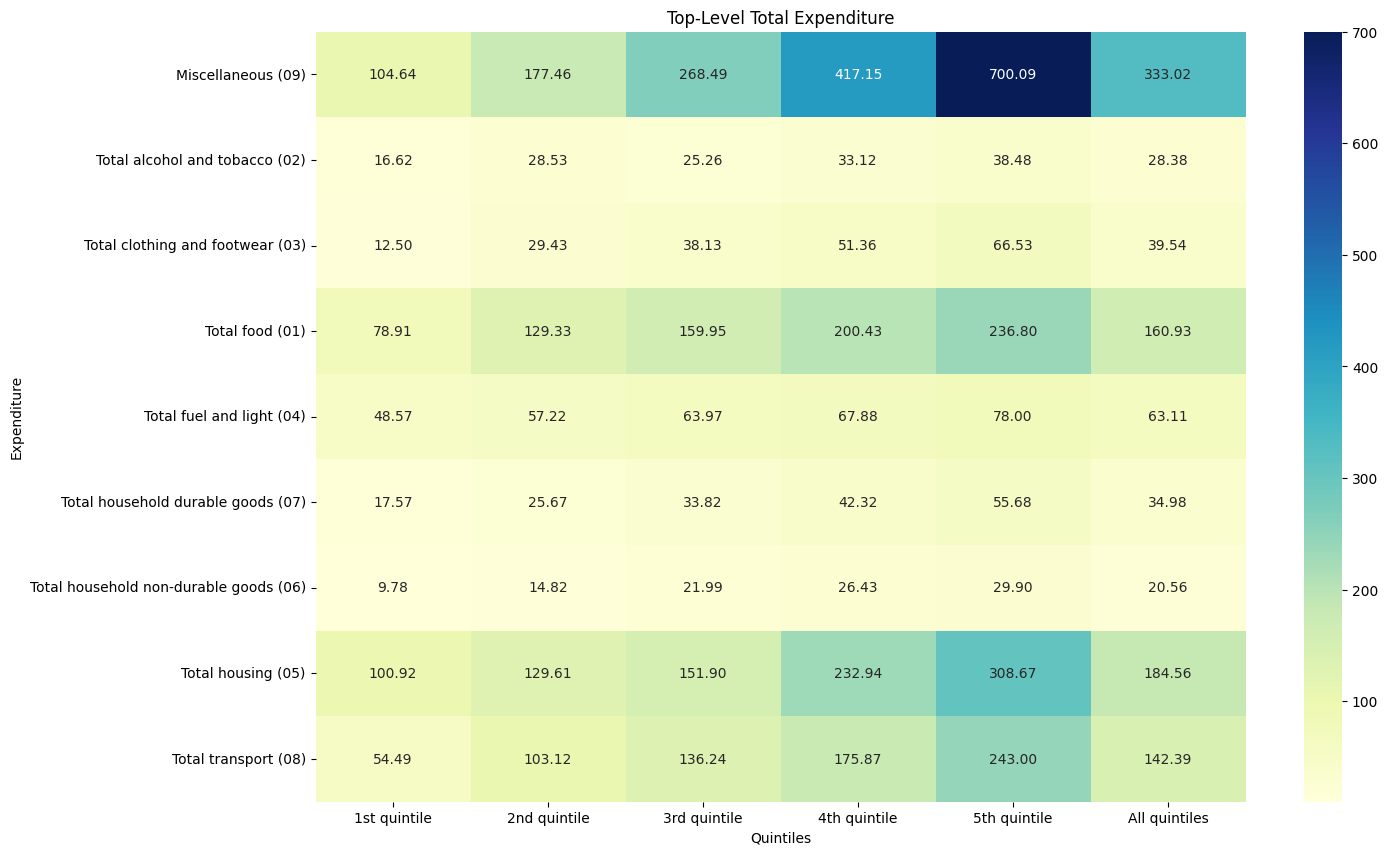

In [ ]:
# Pivot table: rows = Expenditure, columns = Quintiles, values = VALUE
heatmap_data = df_top_level.pivot(index='Expenditure', columns='Quintiles', values='VALUE')

# Plot heatmap
plt.figure(figsize=(15,10))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Top-Level Total Expenditure")
plt.ylabel("Expenditure")
plt.xlabel("Quintiles")
plt.show()


## Bar Chart

In [ ]:
grouped_by_category = df_year.groupby('Expenditure')  # Replace 'Category' with the actual column name


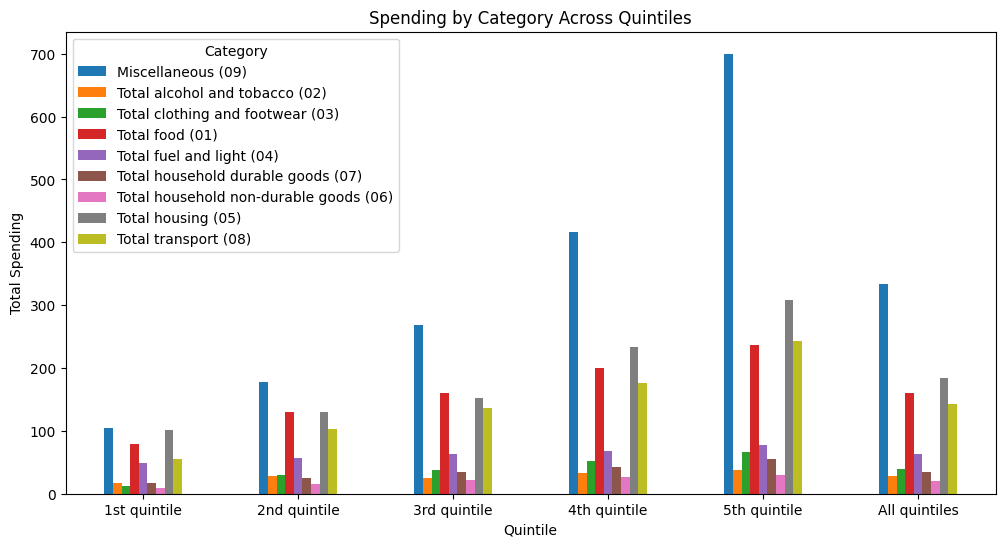

In [ ]:

# Columns: 'Quintile', 'Expenditure', 'VALUE'
df_comp = df_year[df_year['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
# Pivot the DataFrame so that categories are columns, quintiles are rows
df_pivot = df_comp.pivot(index='Quintiles', columns='Expenditure', values='VALUE')

# Plot a grouped bar chart
df_pivot.plot(kind='bar', figsize=(12,6))

plt.title('Spending by Category Across Quintiles')
plt.xlabel('Quintile')
plt.ylabel('Total Spending')
plt.xticks(rotation=0)  # Keep quintile labels horizontal
plt.legend(title='Category', loc='upper left')  # Legend outside
plt.show()


In [ ]:
# Sanity check - is 'all quintiles' all other quintiles
df_misc = df_year[df_year['Expenditure'] == 'Miscellaneous (09)']
all_quintiles_avg = df_misc['VALUE'].mean()
print(all_quintiles_avg)


333.47499999999997


In [ ]:
def plot_barh(dataframe,expenditure,spending):
  # dataframe = dataframe.sort_values(by='VALUE', ascending=False)
  dataframe.plot(
      x = expenditure,
      y = spending,
      kind = 'barh',
      legend = False,
      title = 'Total Spending by Category'
  )

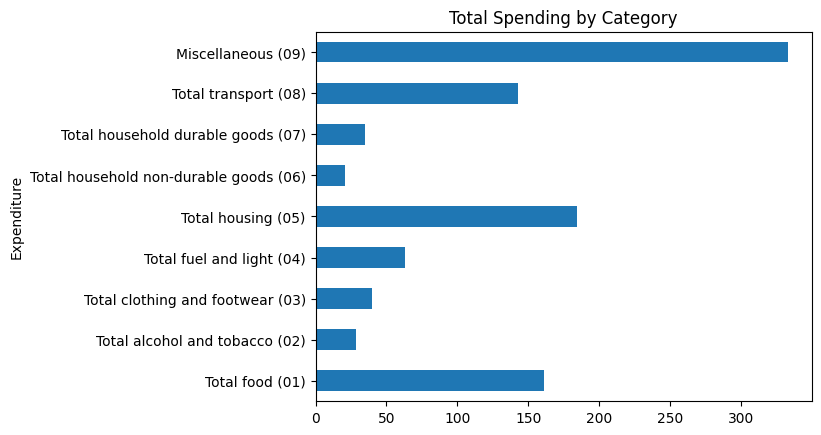

In [ ]:
plot_barh(df_top_level_1,'Expenditure','VALUE')

In [ ]:
# df_1_comp = grouped_by_category.get_group('Total food (01)').copy()
# df_2_comp = grouped_by_category.get_group('Total alcohol and tobacco (02)').copy()
# df_3_comp = grouped_by_category.get_group('Total clothing and footwear (03)').copy()
# df_4_comp = grouped_by_category.get_group('Total fuel and light (04)').copy()
# df_5_comp = grouped_by_category.get_group('Total housing (05)').copy()
# df_6_comp = grouped_by_category.get_group('Total household non-durable goods (06)').copy()
# df_7_comp = grouped_by_category.get_group('Total household durable goods (07)').copy()
# df_8_comp = grouped_by_category.get_group('Total transport (08)').copy()
# df_9_comp = grouped_by_category.get_group('Miscellaneous (09)').copy()


In [ ]:
# df_county = df.groupby("County")["VALUE"].mean().reset_index()

## Pie Charts

In [ ]:
df_top_level_1

,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE
496,Average weekly household expenditure,2023,All quintiles,Total food (01),Euro,160.93
524,Average weekly household expenditure,2023,All quintiles,Total alcohol and tobacco (02),Euro,28.38
527,Average weekly household expenditure,2023,All quintiles,Total clothing and footwear (03),Euro,39.54
528,Average weekly household expenditure,2023,All quintiles,Total fuel and light (04),Euro,63.11
533,Average weekly household expenditure,2023,All quintiles,Total housing (05),Euro,184.56
542,Average weekly household expenditure,2023,All quintiles,Total household non-durable goods (06),Euro,20.56
546,Average weekly household expenditure,2023,All quintiles,Total household durable goods (07),Euro,34.98
557,Average weekly household expenditure,2023,All quintiles,Total transport (08),Euro,142.39
564,Average weekly household expenditure,2023,All quintiles,Miscellaneous (09),Euro,333.02


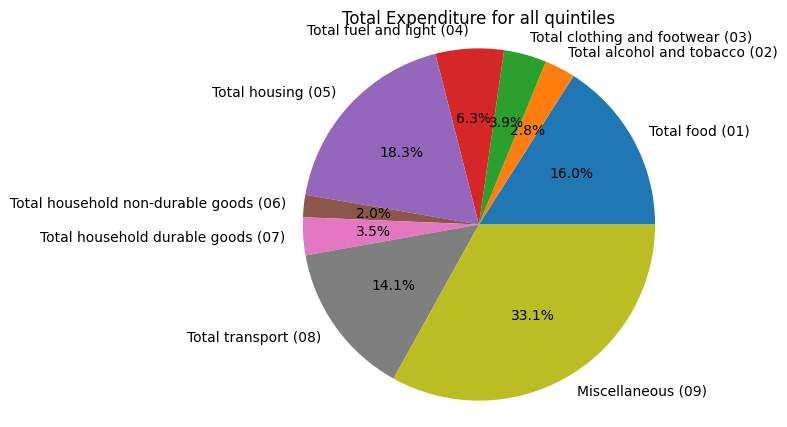

In [ ]:
# Prepare data for pie chart
labels = df_top_level_1['Expenditure']
sizes = df_top_level_1['VALUE']

# Create pie chart
plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=0)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Total Expenditure for all quintiles')
plt.show()

In [ ]:
def plot_pie_charts(quintile_data):
    """
    Output one pie chart per quintile in sequence, with legends, no wedges.
    """
    plt.close('all')


    for quintile_name, data in quintile_data.items():
        labels = data['Expenditure']
        sizes = data['VALUE']

        plt.figure(figsize=(8,8))
        plt.pie(sizes, autopct='%1.1f%%', startangle=140)
        plt.title(quintile_name)


        # Add legend without capturing wedges
        plt.legend(labels, title="Expenditures", loc="upper right")

        plt.tight_layout()
        plt.show()


In [ ]:
# # Group the DataFrame by 'quintile'
grouped_by_quintile = df.groupby('Quintiles')

df_1 = grouped_by_quintile.get_group('1st quintile').copy()
df_2 = grouped_by_quintile.get_group('2nd quintile').copy()
df_3 = grouped_by_quintile.get_group('3rd quintile').copy()
df_4 = grouped_by_quintile.get_group('4th quintile').copy()
df_5 = grouped_by_quintile.get_group('5th quintile').copy()

top_level_1 = df_1[df_1['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
top_level_2 = df_2[df_2['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
top_level_3 = df_3[df_3['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
top_level_4 = df_4[df_4['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()
top_level_5 = df_5[df_5['Expenditure'].apply(lambda x: len(x.split('.')) == 1)].copy()

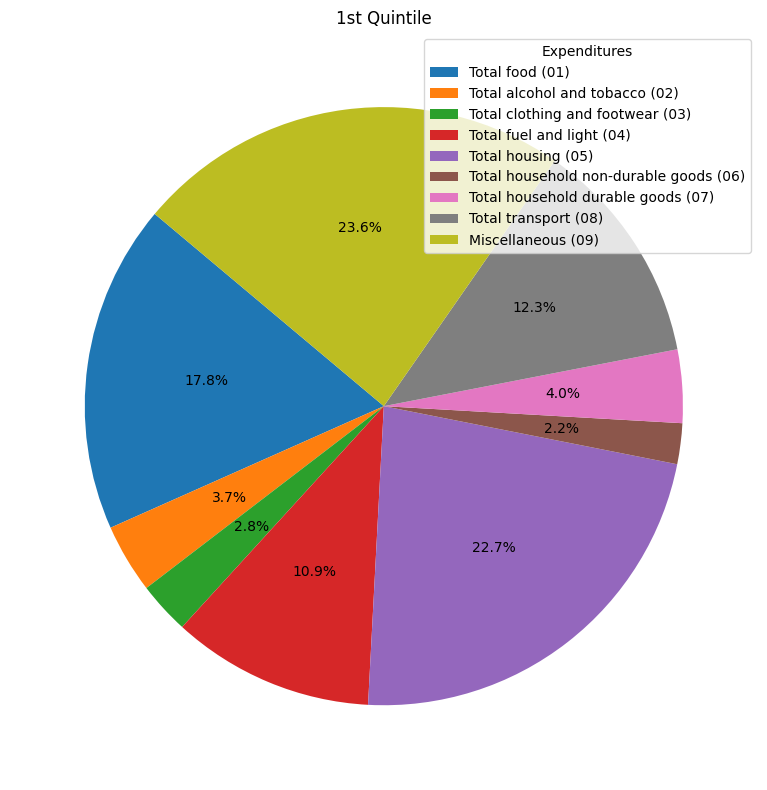

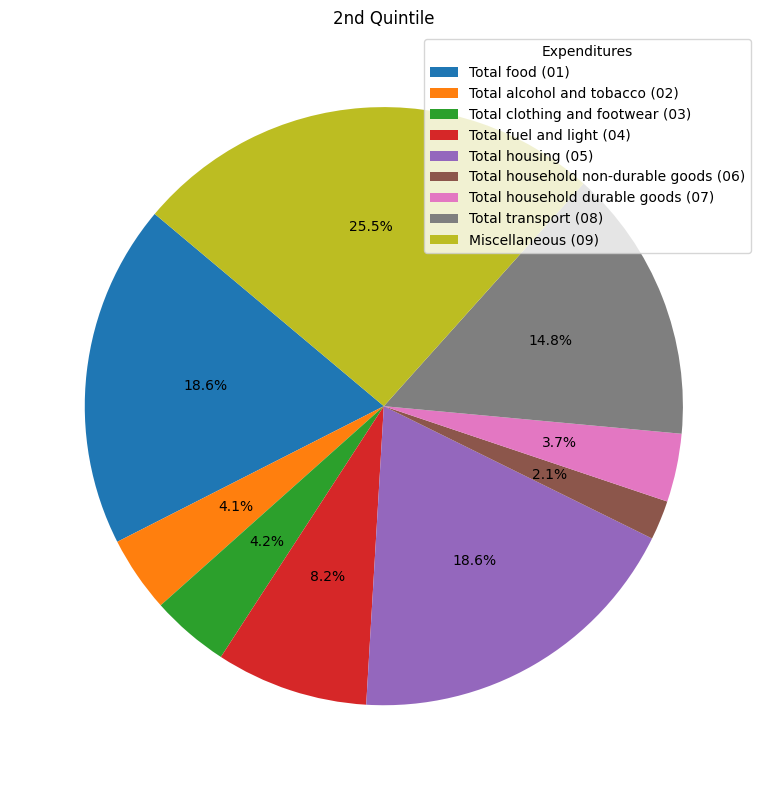

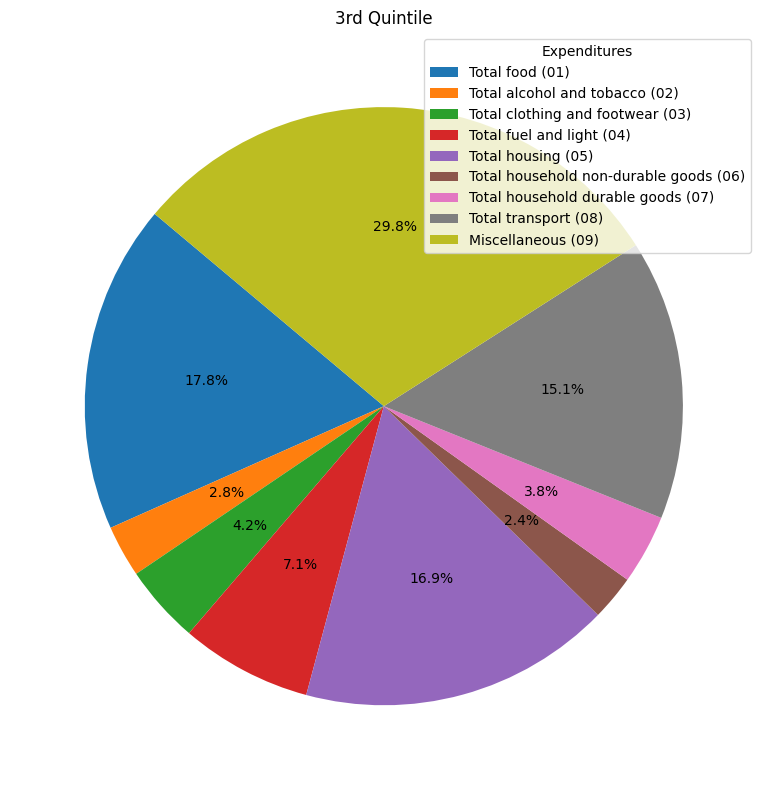

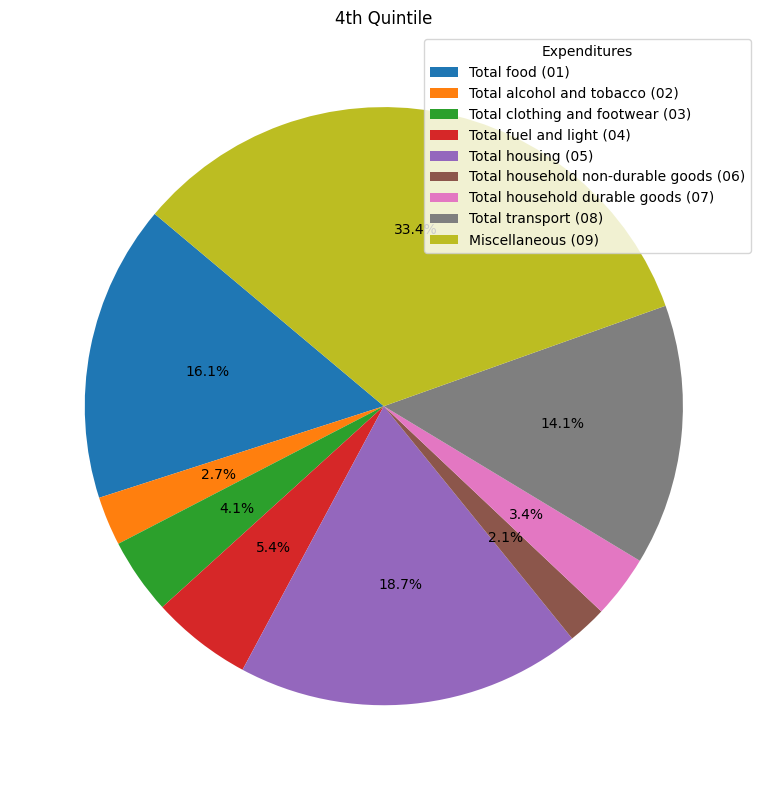

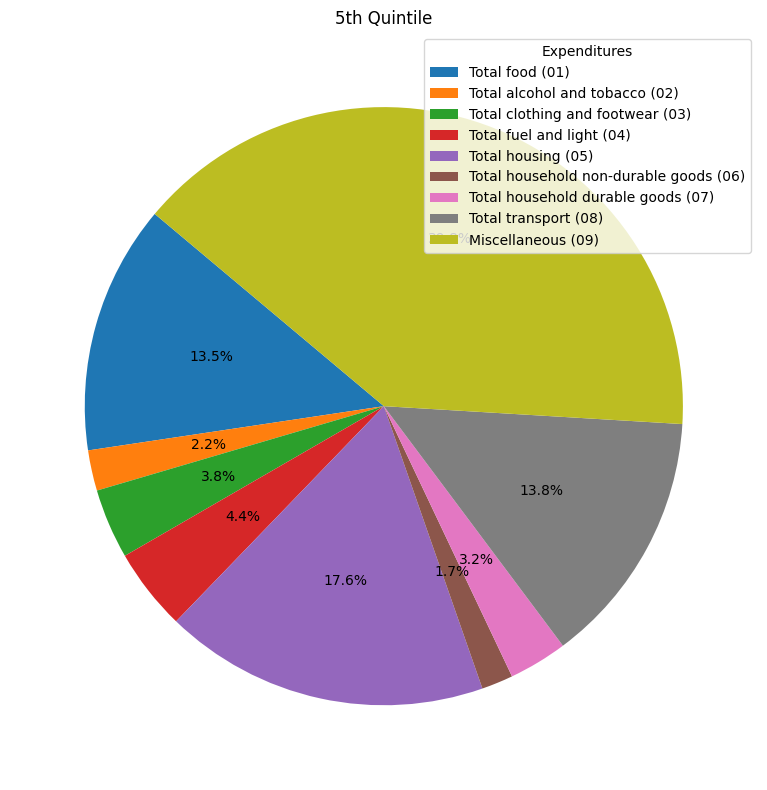

In [ ]:
#admittly, not a good way to best represent data
#might not include in report but mention


# Data for each quintile (assuming top_level_1, top_level_2, etc. DataFrames exist)
quintile_data = {
    '1st Quintile': top_level_1,
    '2nd Quintile': top_level_2,
    '3rd Quintile': top_level_3,
    '4th Quintile': top_level_4,
    '5th Quintile': top_level_5
}
plot_pie_charts(quintile_data)


# Geographics Spread

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 99.9 MB/s eta 0:00:00


<Axes: >

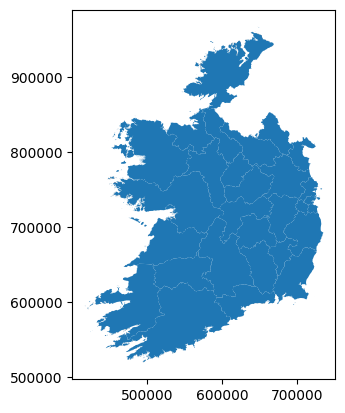

In [ ]:
import geopandas as gpd

# Get local geopjson data
map_df = gpd.read_file('/content/Counties__Boundaries.geojson')
map_df.plot()

# Check top rows

# map_df.plot()

In [ ]:
map_df = gpd.read_file('/content/Counties__Boundaries.geojson')
print(map_df.head())

                  ENGLISH GAEILGE             CONTAE   COUNTY  PROVINCE  \
0     DUBLIN CITY COUNCIL    None  Baile Átha Cliath   DUBLIN  Leinster   
1       CORK CITY COUNCIL    None           Corcaigh     CORK   Munster   
2     GALWAY CITY COUNCIL    None           Gaillimh   GALWAY  Connacht   
3   OFFALY COUNTY COUNCIL    None        Uíbh Fhailí   OFFALY  Leinster   
4  WICKLOW COUNTY COUNCIL    None      Cill Mhantáin  WICKLOW  Leinster   

                                   GUID  CENTROID_X  CENTROID_Y          AREA  \
0  2ae19629-1433-13a3-e055-000000000001   716469.75   735272.06  1.283502e+08   
1  2ae19629-1434-13a3-e055-000000000001   565833.13   571933.83  1.865976e+08   
2  2ae19629-1435-13a3-e055-000000000001   530067.66   726500.52  5.069505e+07   
3  2ae19629-1496-13a3-e055-000000000001   631261.72   709672.35  2.000025e+09   
4  2ae19629-149e-13a3-e055-000000000001   707784.79   690738.10  2.025161e+09   

    CC_ID  ESRI_OID                                           

In [ ]:
counties = map_df['COUNTY'].str.upper().unique()
counties

array(['DUBLIN', 'CORK', 'GALWAY', 'OFFALY', 'WICKLOW', 'TIPPERARY',
       'MONAGHAN', 'SLIGO', 'WEXFORD', 'CLARE', 'DONEGAL', 'MEATH',
       'WESTMEATH', 'MAYO', 'LIMERICK', 'KILDARE', 'KERRY', 'LOUTH',
       'LONGFORD', 'CARLOW', 'LEITRIM', 'KILKENNY', 'LAOIS', 'ROSCOMMON',
       'CAVAN', 'WATERFORD'], dtype=object)

In [ ]:
#copy top level data across quintiles, and add a randomised column of counties
df_country = df_top_level.copy();
df_country['County'] = np.random.choice(counties, size=len(df_country),replace=True)
# df_country



In [ ]:
df_country.columns

Index(['Statistic Label', 'Year', 'Quintiles', 'Expenditure', 'UNIT', 'VALUE',
       'County'],
      dtype='object')

In [ ]:
df_country['County'].unique()
map_df['COUNTY'].unique()

array(['DUBLIN', 'CORK', 'GALWAY', 'OFFALY', 'WICKLOW', 'TIPPERARY',
       'MONAGHAN', 'SLIGO', 'WEXFORD', 'CLARE', 'DONEGAL', 'MEATH',
       'WESTMEATH', 'MAYO', 'LIMERICK', 'KILDARE', 'KERRY', 'LOUTH',
       'LONGFORD', 'CARLOW', 'LEITRIM', 'KILKENNY', 'LAOIS', 'ROSCOMMON',
       'CAVAN', 'WATERFORD'], dtype=object)

In [ ]:
#merge the df_country data with the map_df data to assign geolocated coordinates
map_merged = map_df.merge(df_country, left_on='COUNTY', right_on='County', how='left')
# map_merged

In [ ]:
# To make it easier to visualise, a specified range of expenditure will be set across the counties
# Bin edges
bins = [0, 50, 100, 150, 200, 300, 500, 700]

# Ranges
labels = ['0-50', '50-100', '100-150', '150-200', '200-300', '300-500', '500-700']

# New column with the binned values
map_merged['VALUE_BIN'] = pd.cut(map_merged['VALUE'], bins=bins, labels=labels, include_lowest=True)
# print(map_merged[['COUNTY', 'VALUE', 'VALUE_BIN']].head(10))


## Plot on map

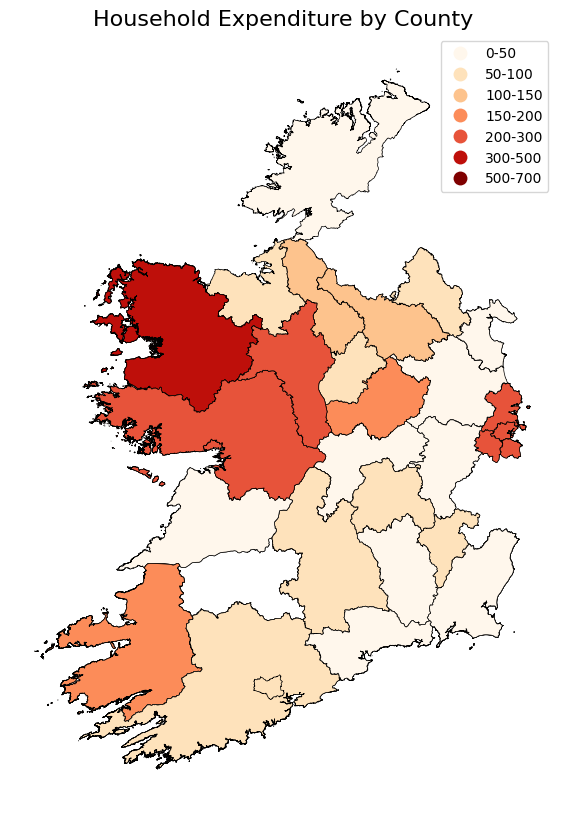

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
map_merged.plot(column='VALUE_BIN',
                cmap='OrRd',
                legend=True,
                edgecolor='black',
                linewidth=0.5,
                ax=ax)

ax.set_title('Household Expenditure by County', fontsize=16)
ax.axis('off')
plt.show()


In [ ]:
map_merged.columns

Index(['ENGLISH', 'GAEILGE', 'CONTAE', 'COUNTY', 'PROVINCE', 'GUID',
       'CENTROID_X', 'CENTROID_Y', 'AREA', 'CC_ID', 'ESRI_OID', 'geometry',
       'Statistic Label', 'Year', 'Quintiles', 'Expenditure', 'UNIT', 'VALUE',
       'County', 'VALUE_BIN'],
      dtype='object')

In [ ]:
map_merged['VALUE'].max()

700.09

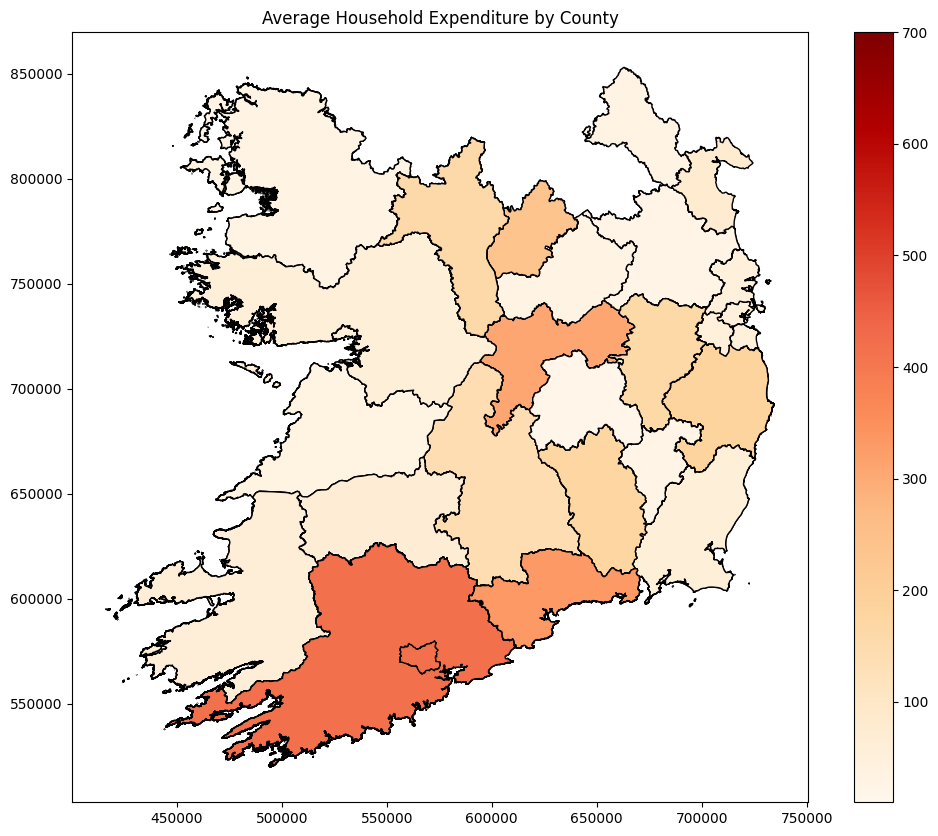

In [ ]:
#The graph visualises expenditure without specified columns,
#less easier to understand

map_merged = map_df.merge(df_country, left_on='COUNTY', right_on='County', how='left')

fig, ax = plt.subplots(figsize=(12, 10))
map_merged.plot(column='VALUE', cmap='OrRd', legend=True, ax=ax, edgecolor='black')
plt.title('Average Household Expenditure by County')
plt.show()


# Unneeded

In [ ]:
df_top_level

,Statistic Label,Year,Quintiles,Expenditure,UNIT,VALUE,County
1,Average weekly household expenditure,2023,1st quintile,Total food (01),Euro,78.91,MONAGHAN
29,Average weekly household expenditure,2023,1st quintile,Total alcohol and tobacco (02),Euro,16.62,KILDARE
32,Average weekly household expenditure,2023,1st quintile,Total clothing and footwear (03),Euro,12.50,CLARE
33,Average weekly household expenditure,2023,1st quintile,Total fuel and light (04),Euro,48.57,KERRY
38,Average weekly household expenditure,2023,1st quintile,Total housing (05),Euro,100.92,WEXFORD
47,Average weekly household expenditure,2023,1st quintile,Total household non-durable goods (06),Euro,9.78,GALWAY
51,Average weekly household expenditure,2023,1st quintile,Total household durable goods (07),Euro,17.57,WATERFORD
62,Average weekly household expenditure,2023,1st quintile,Total transport (08),Euro,54.49,LAOIS
69,Average weekly household expenditure,2023,1st quintile,Miscellaneous (09),Euro,104.64,WICKLOW
100,Average weekly household expenditure,2023,2nd quintile,Total food (01),Euro,129.33,MAYO


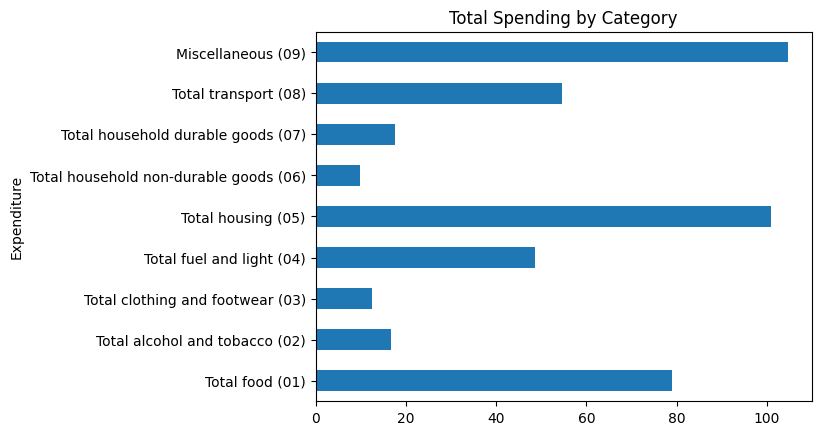

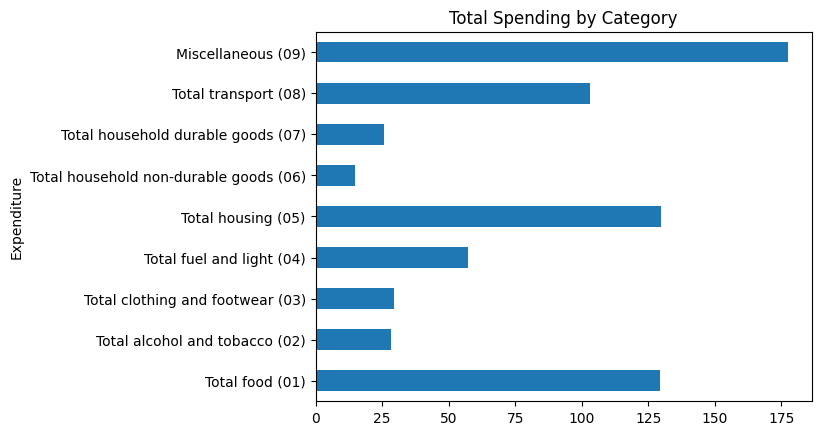

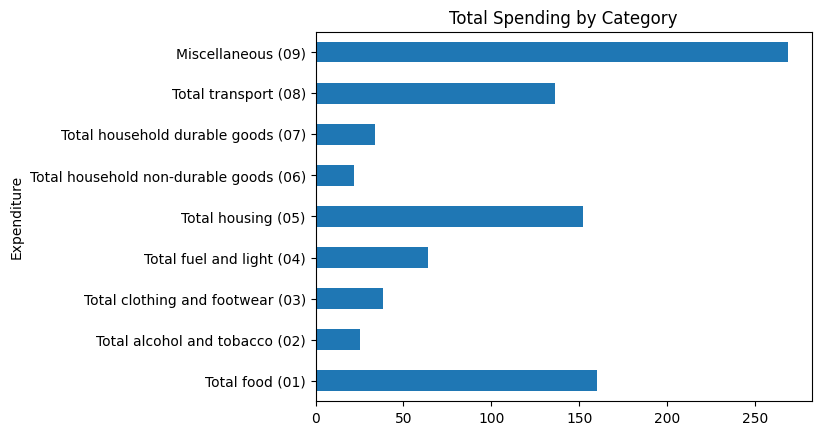

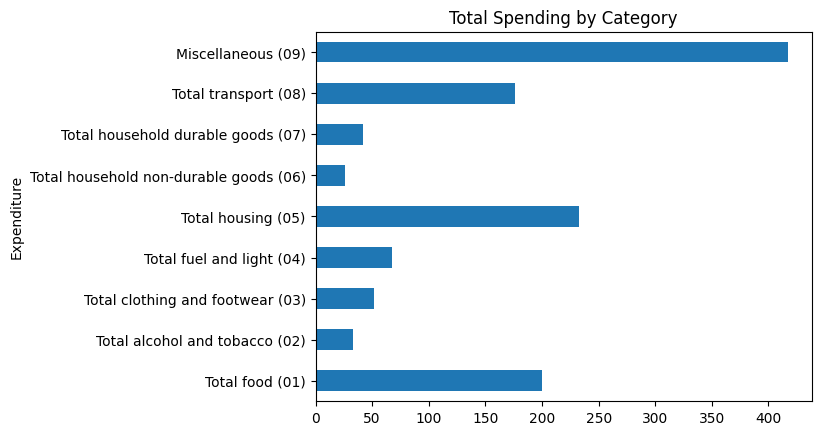

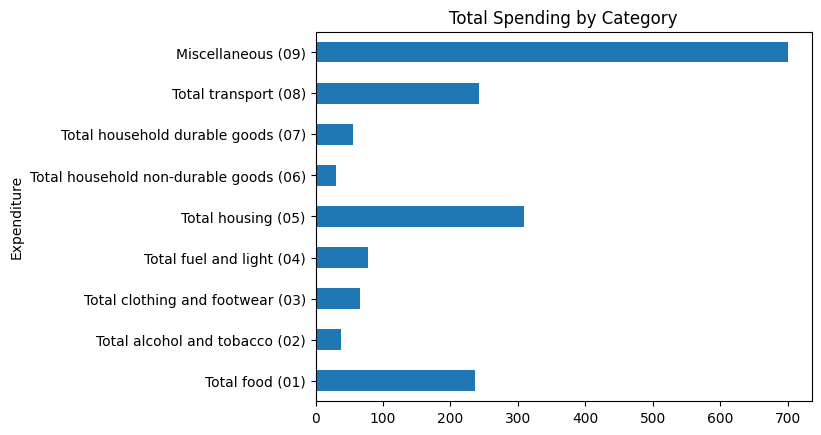

In [ ]:
plot_barh(top_level_1,'Expenditure','VALUE')
plot_barh(top_level_2,'Expenditure','VALUE')
plot_barh(top_level_3,'Expenditure','VALUE')
plot_barh(top_level_4,'Expenditure','VALUE')
plot_barh(top_level_5,'Expenditure','VALUE')
# plot_barh(df_top_level,'Expenditure','VALUE')

In [ ]:
df['Expenditure_Category'] = df['Expenditure'].str.extract(r'\((\d{2})')
grouped_by_category = df.groupby('Expenditure_Category')
display(grouped_by_category.groups.keys())

dict_keys(['00', '01', '02', '03', '04', '05', '06', '07', '08', '09'])